In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Reproducible results
np.random.seed(42)

# Number of records
n = 12000

# Basic categories
products = [f"P{str(i).zfill(3)}" for i in range(1, 31)]

stores = [f"S{str(i).zfill(2)}" for i in range(1, 13)]

sizes = ["S", "M", "L", "XL", "XXL"]

regions = ["North", "South", "East", "West"]

seasons = ["Spring", "Summer", "Autumn", "Winter"]

demographics = [
    "Teen",
    "Young Adult",
    "Adult",
    "Senior"
]

# Store -> Region mapping
store_region = {
    "S01": "South",
    "S02": "South",
    "S03": "South",

    "S04": "North",
    "S05": "North",
    "S06": "North",

    "S07": "East",
    "S08": "East",
    "S09": "East",

    "S10": "West",
    "S11": "West",
    "S12": "West"
}

# Generate dates
dates = pd.date_range(
    start="2023-01-01",
    end="2025-12-31",
    periods=n
)

# Create basic dataframe
df = pd.DataFrame({
    "Date": dates,
    "Product_ID": np.random.choice(products, n),
    "Size": np.random.choice(
        sizes,
        n,
        p=[0.15, 0.35, 0.30, 0.15, 0.05]
    ),
    "Store_ID": np.random.choice(stores, n),
    "Season": np.random.choice(seasons, n),
    "Customer_Demographics": np.random.choice(
        demographics,
        n
    )
})

# Add region based on store
df["Region"] = df["Store_ID"].map(store_region)

# --------------------------------
# Generate realistic Units Sold
# --------------------------------

# Size effect
size_effect = {
    "S": 18,
    "M": 38,
    "L": 32,
    "XL": 22,
    "XXL": 10
}

# Season effect
season_effect = {
    "Spring": 5,
    "Summer": 8,
    "Autumn": 4,
    "Winter": 10
}

# Region effect
region_effect = {
    "North": 4,
    "South": 7,
    "East": 3,
    "West": 6
}

# Customer demographic effect
demographic_effect = {
    "Teen": 2,
    "Young Adult": 7,
    "Adult": 5,
    "Senior": 1
}

# Product effect
product_effect = {
    product: np.random.randint(0, 10)
    for product in products
}

# Generate sales
df["Units_Sold"] = (
    df["Size"].map(size_effect)
    + df["Season"].map(season_effect)
    + df["Region"].map(region_effect)
    + df["Customer_Demographics"].map(demographic_effect)
    + df["Product_ID"].map(product_effect)
    + np.random.randint(0, 15, n)
)

# --------------------------------
# Generate Return Status
# --------------------------------

# Different sizes have different return probabilities
return_probability = {
    "S": 0.05,
    "M": 0.04,
    "L": 0.06,
    "XL": 0.12,
    "XXL": 0.10
}

df["Return_Status"] = [
    "Yes"
    if np.random.random() < return_probability[size]
    else "No"
    for size in df["Size"]
]

# --------------------------------
# Add Year and Month
# --------------------------------

df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

# Display first 10 rows
df.head(10)

,Date,Product_ID,Size,Store_ID,Season,Customer_Demographics,Region,Units_Sold,Return_Status,Year,Month
0,2023-01-01 00:00:00.000000000,P007,M,S10,Winter,Teen,West,70,No,2023,1
1,2023-01-01 02:11:24.657054754,P020,M,S10,Winter,Young Adult,West,68,No,2023,1
2,2023-01-01 04:22:49.314109509,P029,L,S05,Spring,Young Adult,North,57,No,2023,1
3,2023-01-01 06:34:13.971164263,P015,L,S10,Autumn,Adult,West,62,No,2023,1
4,2023-01-01 08:45:38.628219018,P011,L,S06,Summer,Teen,North,55,No,2023,1
5,2023-01-01 10:57:03.285273772,P008,M,S04,Winter,Senior,North,56,No,2023,1
6,2023-01-01 13:08:27.942328527,P029,L,S03,Spring,Young Adult,South,62,No,2023,1
7,2023-01-01 15:19:52.599383281,P021,S,S05,Winter,Senior,North,44,No,2023,1
8,2023-01-01 17:31:17.256438036,P007,M,S07,Spring,Young Adult,East,63,No,2023,1
9,2023-01-01 19:42:41.913492791,P026,L,S11,Summer,Adult,West,62,No,2023,1


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (12000, 11)


In [5]:
from google.colab import files

df.to_csv("fashion_sales_dataset.csv", index=False)
files.download("fashion_sales_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
df.head(10)

,Date,Product_ID,Size,Store_ID,Season,Customer_Demographics,Region,Units_Sold,Return_Status,Year,Month
0,2023-01-01 00:00:00.000000000,P007,M,S10,Winter,Teen,West,70,No,2023,1
1,2023-01-01 02:11:24.657054754,P020,M,S10,Winter,Young Adult,West,68,No,2023,1
2,2023-01-01 04:22:49.314109509,P029,L,S05,Spring,Young Adult,North,57,No,2023,1
3,2023-01-01 06:34:13.971164263,P015,L,S10,Autumn,Adult,West,62,No,2023,1
4,2023-01-01 08:45:38.628219018,P011,L,S06,Summer,Teen,North,55,No,2023,1
5,2023-01-01 10:57:03.285273772,P008,M,S04,Winter,Senior,North,56,No,2023,1
6,2023-01-01 13:08:27.942328527,P029,L,S03,Spring,Young Adult,South,62,No,2023,1
7,2023-01-01 15:19:52.599383281,P021,S,S05,Winter,Senior,North,44,No,2023,1
8,2023-01-01 17:31:17.256438036,P007,M,S07,Spring,Young Adult,East,63,No,2023,1
9,2023-01-01 19:42:41.913492791,P026,L,S11,Summer,Adult,West,62,No,2023,1


In [7]:
print(df.columns.tolist())

['Date', 'Product_ID', 'Size', 'Store_ID', 'Season', 'Customer_Demographics', 'Region', 'Units_Sold', 'Return_Status', 'Year', 'Month']


In [8]:
df.to_csv(
    "fashion_sales_dataset.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [9]:
from google.colab import files

files.download("fashion_sales_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   12000 non-null  datetime64[ns]
 1   Product_ID             12000 non-null  object        
 2   Size                   12000 non-null  object        
 3   Store_ID               12000 non-null  object        
 4   Season                 12000 non-null  object        
 5   Customer_Demographics  12000 non-null  object        
 6   Region                 12000 non-null  object        
 7   Units_Sold             12000 non-null  int64         
 8   Return_Status          12000 non-null  object        
 9   Year                   12000 non-null  int32         
 10  Month                  12000 non-null  int32         
dtypes: datetime64[ns](1), int32(2), int64(1), object(7)
memory usage: 937.6+ KB


In [11]:
df.isnull().sum()

,0
Date,0
Product_ID,0
Size,0
Store_ID,0
Season,0
Customer_Demographics,0
Region,0
Units_Sold,0
Return_Status,0
Year,0


In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
print(
    "Negative Units Sold:",
    (df["Units_Sold"] < 0).sum()
)

Negative Units Sold: 0


In [14]:
print(df["Size"].value_counts())

Size
M      4238
L      3591
XL     1821
S      1787
XXL     563
Name: count, dtype: int64


In [15]:
print("Stores:")
print(df["Store_ID"].unique())

print("\nRegions:")
print(df["Region"].unique())

Stores:
['S10' 'S05' 'S06' 'S04' 'S03' 'S07' 'S11' 'S02' 'S01' 'S12' 'S08' 'S09']

Regions:
['West' 'North' 'South' 'East']


In [16]:
print(df["Season"].value_counts())

Season
Summer    3080
Winter    3018
Autumn    2967
Spring    2935
Name: count, dtype: int64


In [17]:
df.describe()

,Date,Units_Sold,Year,Month
count,12000,12000.000000,12000.000000,12000.000000
mean,2024-07-01 12:00:00,56.519583,2023.999083,6.517000
min,2023-01-01 00:00:00,18.000000,2023.000000,1.000000
25%,2023-10-01 18:00:00,49.000000,2023.000000,4.000000
50%,2024-07-01 12:00:00,57.000000,2024.000000,7.000000
75%,2025-04-01 06:00:00,64.000000,2025.000000,10.000000
max,2025-12-31 00:00:00,84.000000,2025.000000,12.000000
std,NaN,10.679597,0.815969,3.446888


In [18]:
size_demand = df.groupby("Size")["Units_Sold"].sum()

print(size_demand)

Size
L      211252
M      276234
S       80511
XL      89235
XXL     21003
Name: Units_Sold, dtype: int64


In [19]:
size_percentage = (
    size_demand / size_demand.sum()
) * 100

print(size_percentage.round(2))

Size
L      31.15
M      40.73
S      11.87
XL     13.16
XXL     3.10
Name: Units_Sold, dtype: float64


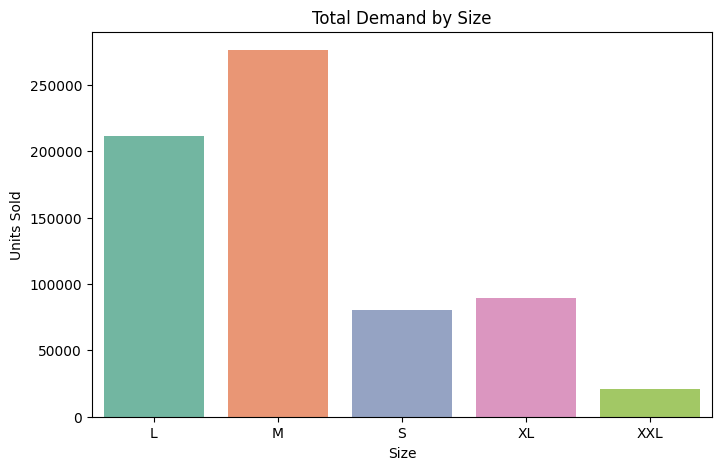

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=size_demand.index,
    y=size_demand.values,
    palette="Set2"
)

plt.title("Total Demand by Size")
plt.xlabel("Size")
plt.ylabel("Units Sold")
plt.show()

In [22]:
region_size = pd.pivot_table(
    df,
    values="Units_Sold",
    index="Region",
    columns="Size",
    aggfunc="sum",
    fill_value=0
)

region_size

Size,L,M,S,XL,XXL
Region,,,,,
East,52745,64848,18931,20839,5137
North,51197,71950,21106,21105,5035
South,52260,69338,19118,23590,5182
West,55050,70098,21356,23701,5649


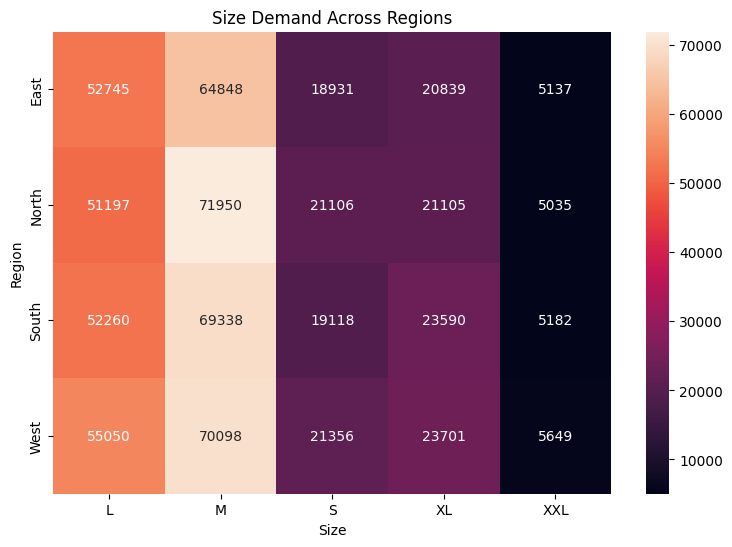

In [23]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    region_size,
    annot=True,
    fmt=".0f"
)

plt.title("Size Demand Across Regions")
plt.xlabel("Size")
plt.ylabel("Region")

plt.show()

In [24]:
season_size = pd.pivot_table(
    df,
    values="Units_Sold",
    index="Season",
    columns="Size",
    aggfunc="sum",
    fill_value=0
)

season_size

Size,L,M,S,XL,XXL
Season,,,,,
Autumn,49831,64175,19626,21071,4327
Spring,49570,65963,19510,21052,4810
Summer,54452,73058,21391,23722,5486
Winter,57399,73038,19984,23390,6380


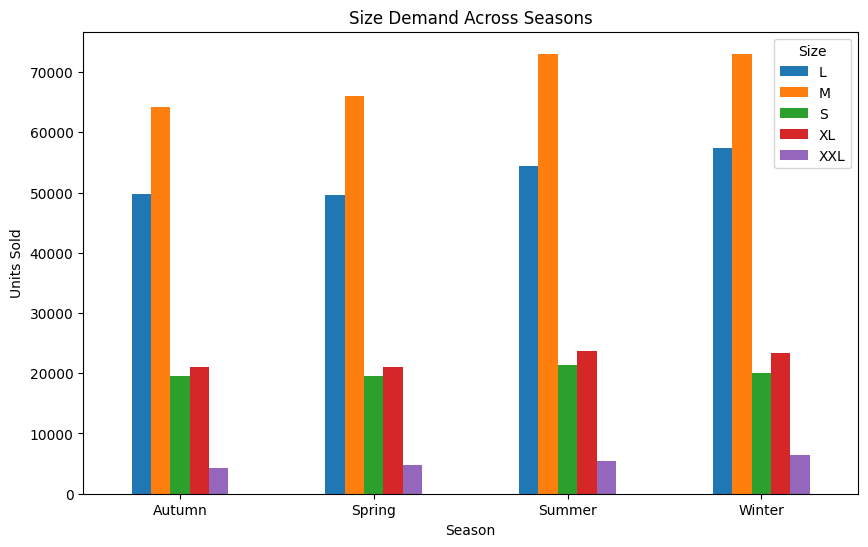

In [25]:
season_size.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Size Demand Across Seasons")
plt.xlabel("Season")
plt.ylabel("Units Sold")

plt.xticks(rotation=0)

plt.show()

In [26]:
return_rate = df.groupby(
    ["Product_ID", "Size"]
)["Return_Status"].apply(
    lambda x: (x == "Yes").mean() * 100
)

return_rate = return_rate.reset_index(
    name="Return_Rate"
)

return_rate.head()

,Product_ID,Size,Return_Rate
0,P001,L,7.000000
1,P001,M,8.724832
2,P001,S,5.660377
3,P001,XL,10.204082
4,P001,XXL,4.347826


In [27]:
return_rate.sort_values(
    "Return_Rate",
    ascending=False
).head(10)

,Product_ID,Size,Return_Rate
134,P027,XXL,29.411765
104,P021,XXL,26.666667
99,P020,XXL,23.809524
19,P004,XXL,20.833333
124,P025,XXL,19.047619
114,P023,XXL,18.750000
44,P009,XXL,18.181818
69,P014,XXL,17.647059
24,P005,XXL,17.647059
43,P009,XL,17.391304


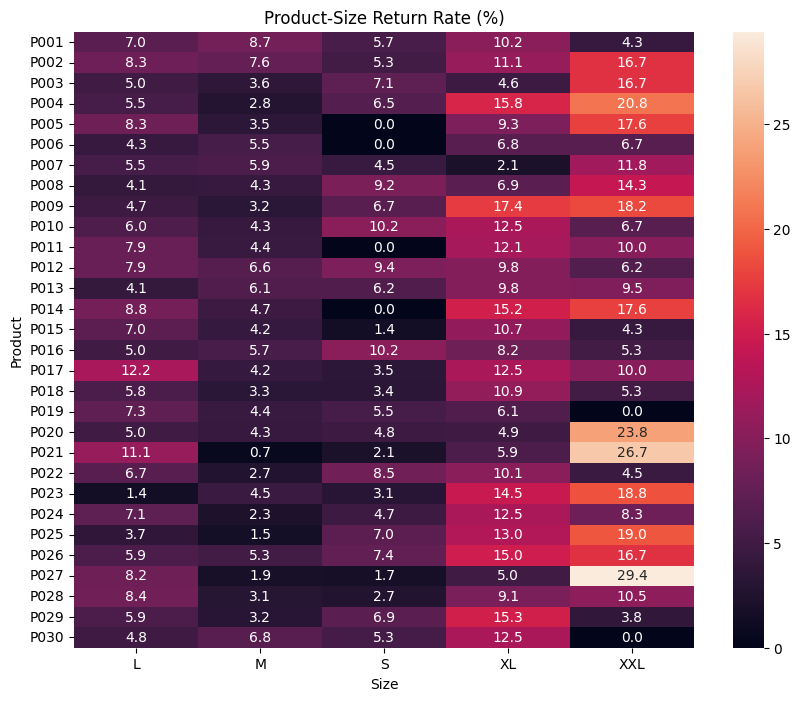

In [28]:
return_table = df.pivot_table(
    values="Return_Status",
    index="Product_ID",
    columns="Size",
    aggfunc=lambda x: (x == "Yes").mean() * 100
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    return_table,
    annot=True,
    fmt=".1f"
)

plt.title("Product-Size Return Rate (%)")
plt.xlabel("Size")
plt.ylabel("Product")

plt.show()

In [30]:
features = [
    "Product_ID",
    "Size",
    "Store_ID",
    "Region",
    "Season",
    "Customer_Demographics",
    "Month"
]

X = df[features]

y = df["Units_Sold"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (9600, 7)
Testing data: (2400, 7)


In [32]:
categorical_features = [
    "Product_ID",
    "Size",
    "Store_ID",
    "Region",
    "Season",
    "Customer_Demographics"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [33]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [34]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

In [35]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

In [37]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[39.75 55.45 49.7  49.78 42.34 54.04 42.57 64.57 55.22 56.21]


In [38]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

In [39]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

In [40]:
r2 = r2_score(
    y_test,
    y_pred
)

In [42]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Random Forest Evaluation")
print("------------------------")
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 2))

Random Forest Evaluation
------------------------
MAE  : 4.09
RMSE : 4.92
R²   : 0.79


In [43]:
store_size_demand = df.groupby(
    ["Store_ID", "Size"]
)["Units_Sold"].sum().reset_index()

store_size_demand.head(10)

,Store_ID,Size,Units_Sold
0,S01,L,16765
1,S01,M,23075
2,S01,S,6273
3,S01,XL,7326
4,S01,XXL,1569
5,S02,L,16385
6,S02,M,22031
7,S02,S,6289
8,S02,XL,7898
9,S02,XXL,1920


In [45]:
store_size_demand["Size_Mix_Percentage"] = (
    store_size_demand["Units_Sold"]
    /
    store_size_demand.groupby("Store_ID")["Units_Sold"]
    .transform("sum")
) * 100

In [46]:
selected_store = "S01"

recommendation = store_size_demand[
    store_size_demand["Store_ID"] == selected_store
].copy()

recommendation

,Store_ID,Size,Units_Sold,Size_Mix_Percentage
0,S01,L,16765,30.477385
1,S01,M,23075,41.948444
2,S01,S,6273,11.403796
3,S01,XL,7326,13.318063
4,S01,XXL,1569,2.852312


In [47]:
total_stock = 1000

recommendation["Recommended_Stock"] = (
    recommendation["Size_Mix_Percentage"]
    / 100
) * total_stock

recommendation

,Store_ID,Size,Units_Sold,Size_Mix_Percentage,Recommended_Stock
0,S01,L,16765,30.477385,304.773851
1,S01,M,23075,41.948444,419.484439
2,S01,S,6273,11.403796,114.037958
3,S01,XL,7326,13.318063,133.180628
4,S01,XXL,1569,2.852312,28.523124


In [48]:
print("KEY INSIGHTS")
print("=" * 50)

# 1. Highest demand size
highest_size = size_demand.idxmax()
highest_demand = size_demand.max()

print(f"1. {highest_size} size has the highest overall demand "
      f"with {highest_demand} units sold.")

# 2. Lowest demand size
lowest_size = size_demand.idxmin()
lowest_demand = size_demand.min()

print(f"2. {lowest_size} size has the lowest overall demand "
      f"with {lowest_demand} units sold.")

# 3. Highest demand region
region_demand = df.groupby("Region")["Units_Sold"].sum()
highest_region = region_demand.idxmax()

print(f"3. {highest_region} region has the highest total demand.")

# 4. Highest demand season
season_demand = df.groupby("Season")["Units_Sold"].sum()
highest_season = season_demand.idxmax()

print(f"4. {highest_season} has the highest overall sales demand.")

# 5. Highest return product-size combination
top_return = return_rate.sort_values(
    "Return_Rate",
    ascending=False
).iloc[0]

print(f"5. {top_return['Product_ID']} in size "
      f"{top_return['Size']} has the highest return rate "
      f"of {top_return['Return_Rate']:.2f}%.")

# 6. Store with highest demand
store_demand = df.groupby("Store_ID")["Units_Sold"].sum()
highest_store = store_demand.idxmax()

print(f"6. {highest_store} has the highest overall product demand.")

# 7. Most important size for S01
s01_best_size = recommendation.loc[
    recommendation["Size_Mix_Percentage"].idxmax(),
    "Size"
]

print(f"7. For store S01, {s01_best_size} requires the highest "
      f"stock allocation.")

KEY INSIGHTS
1. M size has the highest overall demand with 276234 units sold.
2. XXL size has the lowest overall demand with 21003 units sold.
3. West region has the highest total demand.
4. Winter has the highest overall sales demand.
5. P027 in size XXL has the highest return rate of 29.41%.
6. S05 has the highest overall product demand.
7. For store S01, M requires the highest stock allocation.


In [49]:
print("RANDOM FOREST MODEL EVALUATION")
print("=" * 40)

print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 2))

RANDOM FOREST MODEL EVALUATION
MAE  : 4.09
RMSE : 4.92
R²   : 0.79


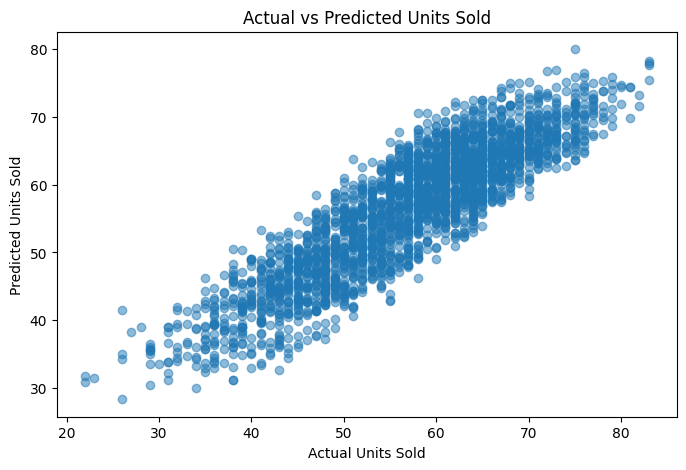

In [50]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Actual vs Predicted Units Sold")

plt.show()

In [51]:
import joblib

joblib.dump(pipeline, "fashion_random_forest_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [52]:
from google.colab import files

files.download("fashion_random_forest_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>